# Thompson Sampling

## UCB vs. Thompson Sampling

Both are solutions to the **multi-armed bandit problem**: at each round you must pick one of `d` ads (arms) to show, observe a reward (1 = click, 0 = no click), and want to maximize cumulative reward over `N` rounds — i.e. balance *exploring* uncertain ads against *exploiting* the ad that looks best so far.

|                        | UCB (Upper Confidence Bound)                                   | Thompson Sampling                                                        |
|------------------------|------------------------------------------------------------------|----------------------------------------------------------------------------|
| Approach               | Deterministic — always picks the ad with the highest upper confidence bound | Probabilistic — samples a value from each ad's reward distribution, picks the highest sample |
| Update rule            | Needs the *cumulative* history at every round (recomputed each round) | Only needs the counts from the *last* round (`numbers_of_rewards_1/0`), easy to update incrementally |
| Exploration mechanism  | Optimism in the face of uncertainty: `delta_i = sqrt(3/2 * log(n+1) / n_i)` shrinks as an ad gets picked more | Randomness from sampling a Beta(successes+1, failures+1) distribution — wide/flat distribution for under-tried ads means samples can still spike high |
| Cold start              | Forces every ad to be tried once first (`upper_bound = 1e400` when unseen) | No special-casing needed — Beta(1,1) is just a uniform(0,1) prior, so unseen ads are naturally explored |
| Delayed feedback       | Assumes rewards are available immediately every round | Handles delayed/batched reward updates better in practice (a known real-world advantage) |
| Empirical performance  | Solid, but tends to explore more conservatively | Usually converges faster / achieves higher reward on this dataset (see reward totals in each notebook) — generally regarded as the stronger practical algorithm |
| When to use            | When you want a simple, deterministic, easy-to-reason-about bound; fine for stationary problems with immediate feedback | Preferred in most production settings (ad serving, A/B testing, recommendations) for its faster convergence and robustness to delayed data |

Both algorithms are implemented from scratch here (no `numpy.random` built-in bandit library) so you can see the update rules directly — compare this notebook's loop to [upper_confidence_bound.ipynb](../part-6-UCB/upper_confidence_bound.ipynb).

## Importing the libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [4]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

## Implementing Thompson Sampling

**Reading this implementation:**
- `numbers_of_rewards_1[i]` / `numbers_of_rewards_0[i]` are the success/failure counts for ad `i` so far — together they parametrize a `Beta(successes + 1, failures + 1)` distribution (the `+1`s are the uniform prior before any data is seen).
- Each round, `random.betavariate(...)` draws **one random sample** from each ad's Beta distribution; the ad with the highest sample is selected. This is the "sampling" in Thompson Sampling — contrast with UCB's `upper_confidence_bound.ipynb`, which instead computes a deterministic bound (`average_reward + delta_i`) and always argmax's over it, no randomness involved.
- As an ad accumulates more observations, its Beta distribution tightens around the true success rate, so samples become more consistent (less exploration) — the algorithm self-balances explore/exploit without any manual schedule or tuning parameter (UCB's `3/2` constant inside `delta_i` is a tunable knob; Thompson Sampling has none here).

In [11]:
import random
N = 10000
d = 10
ads_selected = []
numbers_of_rewards_1 = [0] * d
numbers_of_rewards_0 = [0] * d
total_reward = 0
for n in range(0, N):
  ad = 0
  max_random = 0
  for i in range(0, d):
    random_beta = random.betavariate(numbers_of_rewards_1[i] + 1, numbers_of_rewards_0[i] + 1)
    if (random_beta > max_random):
      max_random = random_beta
      ad = i
  ads_selected.append(ad)
  reward = dataset.values[n, ad]
  if reward == 1:
    numbers_of_rewards_1[ad] = numbers_of_rewards_1[ad] + 1
  else:
    numbers_of_rewards_0[ad] = numbers_of_rewards_0[ad] + 1
  total_reward = total_reward + reward

## Visualising the results - Histogram

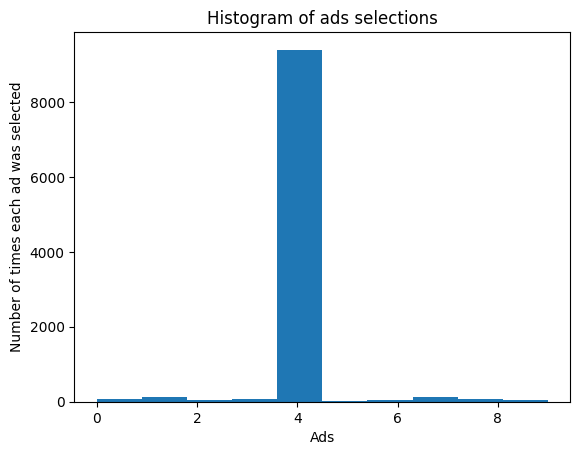

In [12]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()